In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
import joblib

BASE_PATH = "/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/r4.2/"

http = pd.read_csv(BASE_PATH + "http.csv", nrows=100000)
logon = pd.read_csv(BASE_PATH + "logon.csv", nrows=100000)
device = pd.read_csv(BASE_PATH + "device.csv", nrows=100000)
file = pd.read_csv(BASE_PATH + "file.csv", nrows=100000)
email = pd.read_csv(BASE_PATH + "email.csv", nrows=100000)
psychometric = pd.read_csv(BASE_PATH + "psychometric.csv")

print("✅ All datasets loaded successfully!")

✅ All datasets loaded successfully!


In [2]:
datasets = {
    "HTTP": http,
    "LOGON": logon,
    "DEVICE": device,
    "FILE": file,
    "EMAIL": email
}

for name, df in datasets.items():
    print(f"Processing {name}...")

    df["date"] = pd.to_datetime(df["date"])
    df.drop_duplicates(inplace=True)

print("✅ Preprocessing completed!")

Processing HTTP...
Processing LOGON...
Processing DEVICE...
Processing FILE...
Processing EMAIL...
✅ Preprocessing completed!


In [4]:
print("=" * 60)
print("FEATURE ENGINEERING - HTTP")
print("=" * 60)

http["activity_date"] = http["date"].dt.date
http["hour"] = http["date"].dt.hour

# Activity outside office hours
http["after_hours"] = ((http["hour"] < 8) | (http["hour"] > 18)).astype(int)

# Weekend activity
http["weekend"] = (http["date"].dt.dayofweek >= 5).astype(int)

http_daily = (
    http.groupby(["user", "activity_date"])
    .agg(
        http_count=("id", "count"),
        unique_url=("url", "nunique"),
        after_hours_activity=("after_hours", "sum"),
        weekend_activity=("weekend", "sum")
    )
    .reset_index()
)

print(http_daily.head())
print("HTTP Daily Shape:", http_daily.shape)

FEATURE ENGINEERING - HTTP
      user activity_date  http_count  unique_url  after_hours_activity  \
0  AAE0190    2010-01-04         143          54                     0   
1  AAF0535    2010-01-04          29          15                     0   
2  AAF0791    2010-01-04          95          44                     0   
3  AAF0791    2010-01-05           2           2                     0   
4  AAL0706    2010-01-04          10           9                     0   

   weekend_activity  
0                 0  
1                 0  
2                 0  
3                 0  
4                 0  
HTTP Daily Shape: (1684, 6)


In [5]:
print("=" * 60)
print("FEATURE ENGINEERING - LOGON")
print("=" * 60)

logon["activity_date"] = logon["date"].dt.date

logon_daily = (
    logon.groupby(["user", "activity_date"])
    .agg(
        logon_count=("id", "count"),
        unique_pc=("pc", "nunique")
    )
    .reset_index()
)

print(logon_daily.head())
print("LOGON Daily Shape:", logon_daily.shape)

FEATURE ENGINEERING - LOGON
      user activity_date  logon_count  unique_pc
0  AAE0190    2010-01-04            2          1
1  AAE0190    2010-01-05            2          1
2  AAE0190    2010-01-06            2          1
3  AAE0190    2010-01-07            2          1
4  AAE0190    2010-01-08            2          1
LOGON Daily Shape: (38735, 4)


In [6]:
print("=" * 60)
print("FEATURE ENGINEERING - DEVICE")
print("=" * 60)

device["activity_date"] = device["date"].dt.date

device_daily = (
    device.groupby(["user", "activity_date"])
    .agg(
        device_count=("id", "count")
    )
    .reset_index()
)

print(device_daily.head())
print("DEVICE Daily Shape:", device_daily.shape)

FEATURE ENGINEERING - DEVICE
      user activity_date  device_count
0  AAF0535    2010-01-05             4
1  AAF0535    2010-01-06             2
2  AAF0535    2010-01-07             4
3  AAF0535    2010-01-08             8
4  AAF0535    2010-01-11             2
DEVICE Daily Shape: (14076, 3)


In [7]:
print("=" * 60)
print("FEATURE ENGINEERING - FILE")
print("=" * 60)

file["activity_date"] = file["date"].dt.date

file_daily = (
    file.groupby(["user", "activity_date"])
    .agg(
        file_count=("id", "count"),
        unique_files=("filename", "nunique")
    )
    .reset_index()
)

print(file_daily.head())
print("FILE Daily Shape:", file_daily.shape)

FEATURE ENGINEERING - FILE
      user activity_date  file_count  unique_files
0  AAF0535    2010-01-05           1             1
1  AAF0535    2010-01-06           5             5
2  AAF0535    2010-01-07           1             1
3  AAF0535    2010-01-08           3             3
4  AAF0535    2010-01-12           2             2
FILE Daily Shape: (10487, 4)


In [8]:
print("=" * 60)
print("FEATURE ENGINEERING - EMAIL")
print("=" * 60)

email["activity_date"] = email["date"].dt.date

email_daily = (
    email.groupby(["user", "activity_date"])
    .agg(
        email_count=("id", "count"),
        unique_receivers=("to", "nunique"),
        total_attachment=("attachments", "sum")
    )
    .reset_index()
)

print(email_daily.head())
print("EMAIL Daily Shape:", email_daily.shape)

FEATURE ENGINEERING - EMAIL
      user activity_date  email_count  unique_receivers  total_attachment
0  AAE0190    2010-01-04           14                14                 4
1  AAE0190    2010-01-05           13                13                 2
2  AAE0190    2010-01-06           14                11                12
3  AAE0190    2010-01-07           14                13                 9
4  AAE0190    2010-01-08           13                11                10
EMAIL Daily Shape: (12699, 5)


In [9]:
print("=" * 60)
print("MERGING ALL FEATURES")
print("=" * 60)

daily = http_daily.merge(
    logon_daily,
    on=["user", "activity_date"],
    how="outer"
)

daily = daily.merge(
    device_daily,
    on=["user", "activity_date"],
    how="outer"
)

daily = daily.merge(
    file_daily,
    on=["user", "activity_date"],
    how="outer"
)

daily = daily.merge(
    email_daily,
    on=["user", "activity_date"],
    how="outer"
)

daily.fillna(0, inplace=True)

print("Daily Dataset Shape:", daily.shape)
daily.head()

MERGING ALL FEATURES
Daily Dataset Shape: (45995, 14)


,user,activity_date,http_count,unique_url,after_hours_activity,weekend_activity,logon_count,unique_pc,device_count,file_count,unique_files,email_count,unique_receivers,total_attachment
0,AAE0190,2010-01-04,143.0,54.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,14.0,14.0,4.0
1,AAE0190,2010-01-05,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,13.0,13.0,2.0
2,AAE0190,2010-01-06,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,14.0,11.0,12.0
3,AAE0190,2010-01-07,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,14.0,13.0,9.0
4,AAE0190,2010-01-08,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,13.0,11.0,10.0


In [10]:
daily.to_csv("/kaggle/working/daily_features.csv", index=False)

print("✅ daily_features.csv saved successfully!")

✅ daily_features.csv saved successfully!


In [11]:
insiders = pd.read_csv(
    "/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/insiders.csv"
)

print(insiders.head())
print(insiders.shape)

   dataset  scenario     details     user                start  \
0      2.0         1      r2.csv  ONS0995     3/6/2010 1:41:56   
1      3.1         1  r3.1-1.csv  CSF0929  07/01/2010 01:24:58   
2      3.1         2  r3.1-2.csv  CCH0959  08/02/2010 10:34:31   
3      3.2         1  r3.2-1.csv  RCW0822  09/29/2010 21:10:27   
4      3.2         2  r3.2-2.csv  JCE0258  07/12/2010 08:16:02   

                   end  
0    3/20/2010 8:10:12  
1  07/16/2010 06:52:00  
2  09/30/2010 15:04:03  
3  10/15/2010 06:34:52  
4  09/03/2010 16:16:29  
(191, 6)


In [12]:
insiders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   dataset   191 non-null    float64
 1   scenario  191 non-null    int64  
 2   details   191 non-null    object 
 3   user      191 non-null    object 
 4   start     191 non-null    object 
 5   end       191 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.1+ KB


In [13]:
print("=" * 60)
print("CREATING LABELS")
print("=" * 60)

# Create label column
daily["label"] = daily["user"].isin(insiders["user"]).astype(int)

print(daily["label"].value_counts())

daily.head()

CREATING LABELS
label
0    41976
1     4019
Name: count, dtype: int64


,user,activity_date,http_count,unique_url,after_hours_activity,weekend_activity,logon_count,unique_pc,device_count,file_count,unique_files,email_count,unique_receivers,total_attachment,label
0,AAE0190,2010-01-04,143.0,54.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,14.0,14.0,4.0,0
1,AAE0190,2010-01-05,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,13.0,13.0,2.0,0
2,AAE0190,2010-01-06,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,14.0,11.0,12.0,0
3,AAE0190,2010-01-07,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,14.0,13.0,9.0,0
4,AAE0190,2010-01-08,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,13.0,11.0,10.0,0


In [14]:
X = daily.drop(columns=["user", "activity_date", "label"])

y = daily["label"]

print("Features Shape :", X.shape)
print("Labels Shape   :", y.shape)

Features Shape : (45995, 12)
Labels Shape   : (45995,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(36796, 12)
(9199, 12)


In [16]:
daily["label"].value_counts()

label
0    41976
1     4019
Name: count, dtype: int64

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("✅ Random Forest Model Trained Successfully!")

✅ Random Forest Model Trained Successfully!


In [18]:
y_pred = rf_model.predict(X_test)

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

MODEL EVALUATION
Accuracy : 0.862376345254919
Precision: 0.33936022253129344
Recall   : 0.6069651741293532
F1 Score : 0.43532560214094557

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.89      0.92      8395
           1       0.34      0.61      0.44       804

    accuracy                           0.86      9199
   macro avg       0.65      0.75      0.68      9199
weighted avg       0.91      0.86      0.88      9199



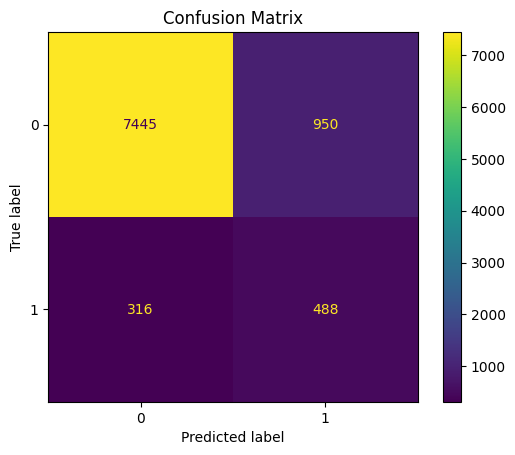

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")
plt.show()

                 Feature  Importance
6           device_count    0.339280
4            logon_count    0.137603
7             file_count    0.112259
5              unique_pc    0.109755
8           unique_files    0.109294
11      total_attachment    0.074535
10      unique_receivers    0.043636
9            email_count    0.039204
1             unique_url    0.015021
0             http_count    0.009516
2   after_hours_activity    0.008901
3       weekend_activity    0.000996


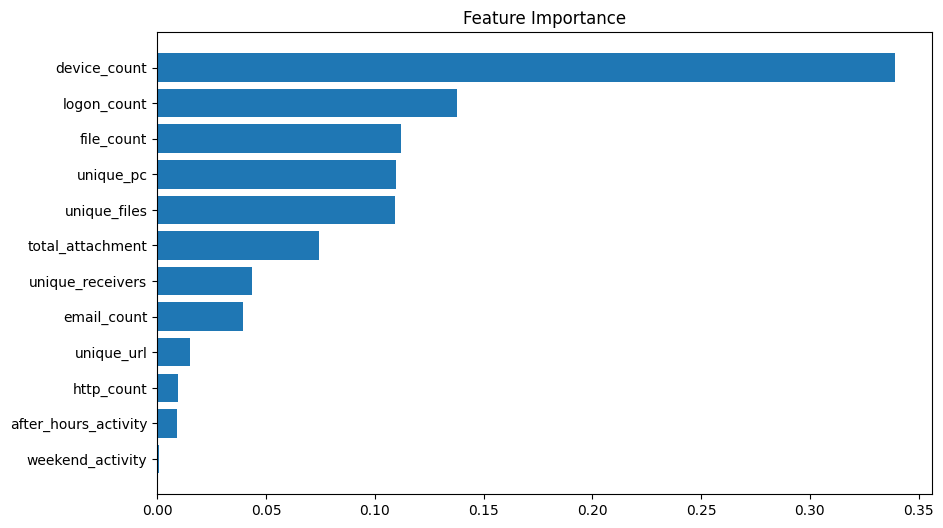

In [21]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(10,6))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

In [22]:
import joblib

joblib.dump(rf_model, "/kaggle/working/insider_threat_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [23]:
import os

print(os.listdir("/kaggle/working"))

['insider_threat_model.pkl', 'daily_features.csv', '.virtual_documents']


In [24]:
!pip install shap

In [25]:
import shap
import joblib
import matplotlib.pyplot as plt

In [26]:
rf_model = joblib.load("/kaggle/working/insider_threat_model.pkl")

In [27]:
explainer = shap.TreeExplainer(rf_model)

In [30]:
sample = X_test.iloc[:100]

shap_values = explainer.shap_values(sample)

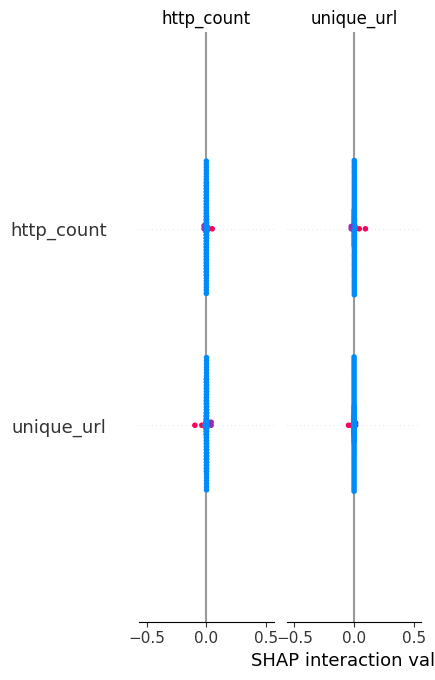

In [31]:
shap.summary_plot(
    shap_values,
    sample,
    plot_type="bar"
)

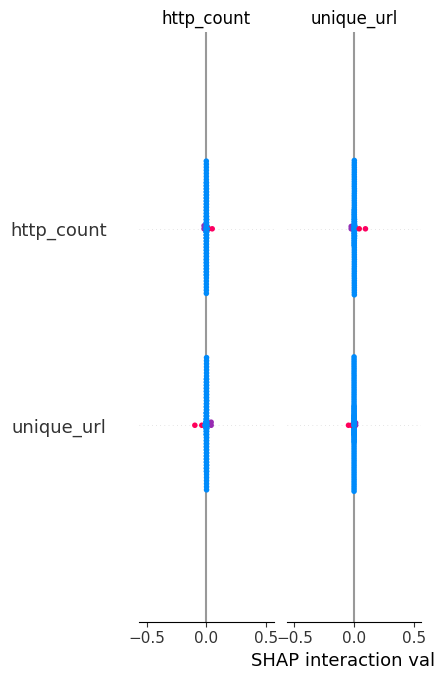

In [32]:
shap.summary_plot(
    shap_values,
    sample
)

In [33]:
import joblib

joblib.dump(rf_model, "/kaggle/working/insider_threat_model.pkl")

['/kaggle/working/insider_threat_model.pkl']